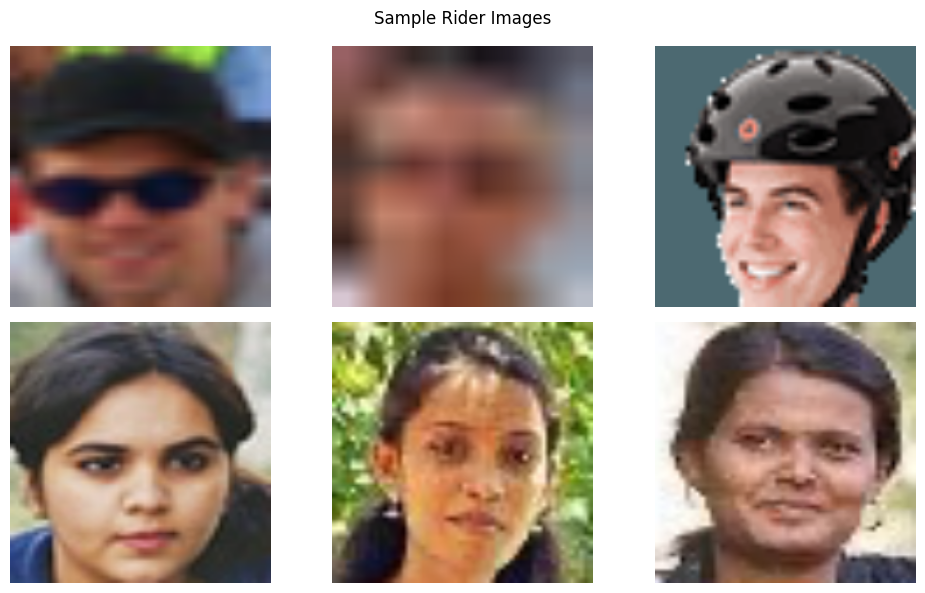

Dataset Shape: (1434, 224, 224, 3) (1434,)


--------------------------------------------------
Table 1: Dataset Summary
--------------------------------------------------


,Property,Value
0,Total Samples,1434
1,Image Size,224x224
2,Classes,2




--------------------------------------------------
Table 2: Class Distribution
--------------------------------------------------


,Class,Count
0,Without Helmet,482
1,With Helmet,952


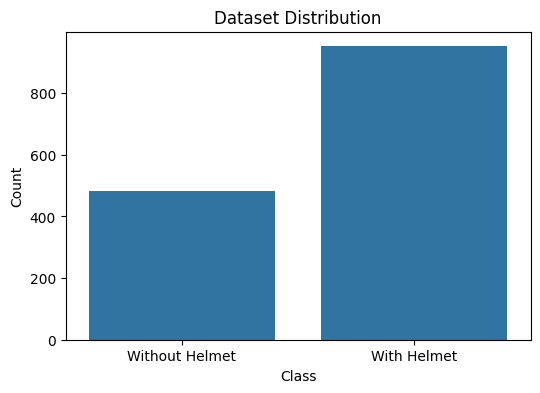

CNN Architecture saved as PDF


--------------------------------------------------
Table 3: CNN Hyperparameters
--------------------------------------------------


,Parameter,Value
0,Image Size,224x224
1,Batch Size,32
2,Epochs,10
3,Optimizer,Adam
4,Loss Function,Binary Crossentropy
5,Dropout,0.3


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.6630 - loss: 0.5889 - val_accuracy: 0.7070 - val_loss: 0.5883
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.7119 - loss: 0.5882 - val_accuracy: 0.6651 - val_loss: 0.6371
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.6820 - loss: 0.5723 - val_accuracy: 0.7163 - val_loss: 0.5723
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.7468 - loss: 0.5172 - val_accuracy: 0.7116 - val_loss: 0.5717
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.7667 - loss: 0.4930 - val_accuracy: 0.7535 - val_loss: 0.5512
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.7807 - loss: 0.4795 - val_accuracy: 0.7302 - val_loss: 0.5178
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.7896 - loss: 0.4729 - val_accuracy: 0.7814 - val_loss: 0.4971
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.7767 - loss: 0.4893 - val_accuracy: 0.7442 - val_loss:

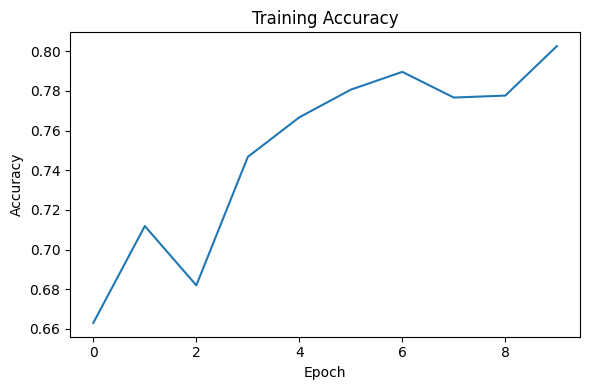

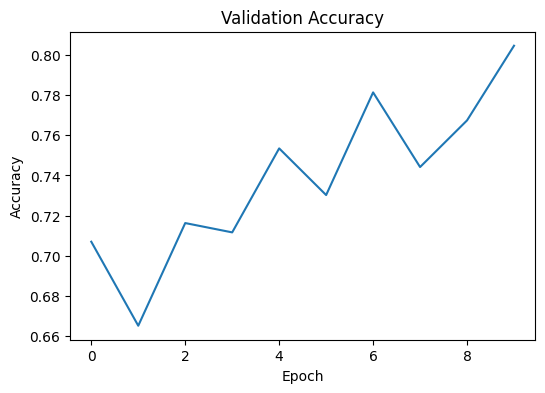

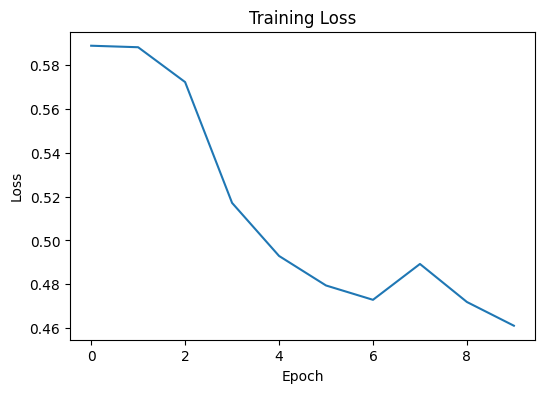

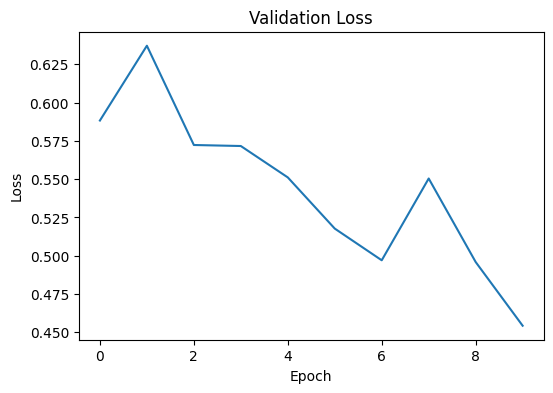

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 563ms/step
              precision    recall  f1-score   support

           0       0.84      0.67      0.75        73
           1       0.85      0.94      0.89       143

    accuracy                           0.85       216
   macro avg       0.85      0.80      0.82       216
weighted avg       0.85      0.85      0.84       216



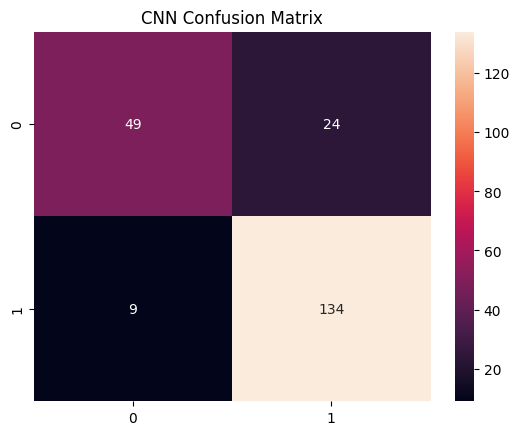

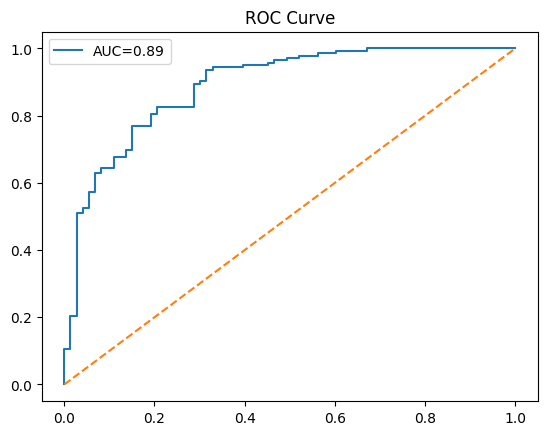

Using layer: last_conv


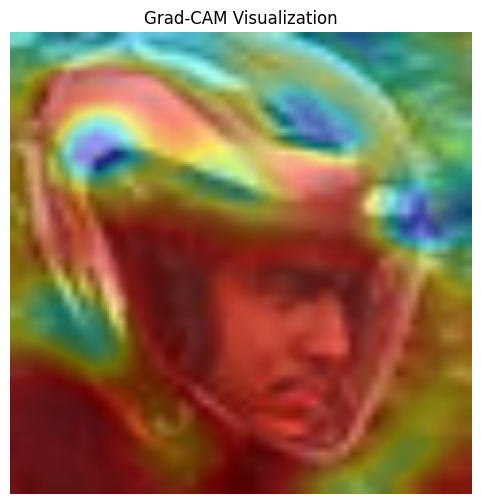

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6560 - loss: 0.6797 - val_accuracy: 0.6651 - val_loss: 0.6669
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 984ms/step - accuracy: 0.6640 - loss: 0.6570 - val_accuracy: 0.6651 - val_loss: 0.6458
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 975ms/step - accuracy: 0.6640 - loss: 0.6430 - val_accuracy: 0.6651 - val_loss: 0.6393
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 839ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        73
           1       0.66      1.00      0.80       143

    accuracy                           0.66       216
   macro avg       0.33      0.50      0.40       216
weighted avg       0.44      0.66      0.53       216



--------------------------------------------------
Table 4: Classification Report
--------------------------------------------------


,precision,recall,f1-score,support
0,0.844828,0.671233,0.748092,73.000000
1,0.848101,0.937063,0.890365,143.000000
accuracy,0.847222,0.847222,0.847222,0.847222
macro avg,0.846464,0.804148,0.819229,216.000000
weighted avg,0.846995,0.847222,0.842282,216.000000




--------------------------------------------------
Table 5: CNN Performance Metrics
--------------------------------------------------


,Metric,Value
0,Accuracy,0.847222




--------------------------------------------------
Table 7: Model Comparison Results
--------------------------------------------------


,Model,Accuracy
0,CNN,0.847222
1,MobileNetV2,0.662037




--------------------------------------------------
Table 6: MobileNetV2 Performance Metrics
--------------------------------------------------


,Metric,Value
0,Accuracy,0.662037


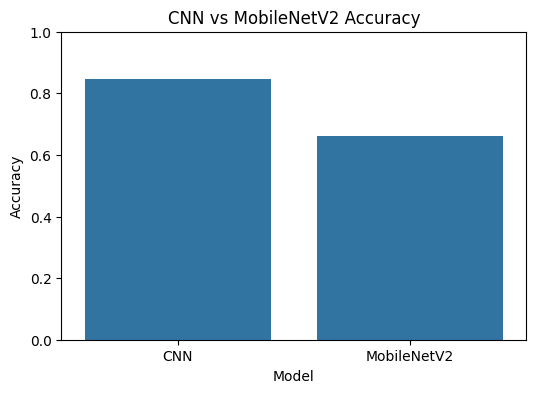

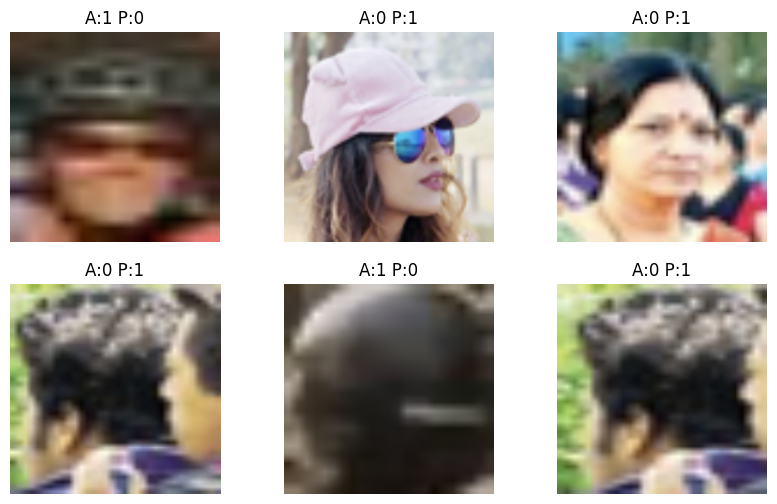

Models saved successfully


In [8]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # hides INFO, WARNING, ERROR logs
os.environ['PYTHONWARNINGS'] = 'ignore'    # hides Python warnings
os.environ['CUDA_VISIBLE_DEVICES'] = '0'   # optional (keep GPU stable)


import tensorflow as tf

import cv2
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc
)

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

# ==========================
# DATASET PATHS
# ==========================
DATASET_PATH = "/kaggle/input/datasets/paaruvg/helmet-dataset"
IMAGE_PATH = os.path.join(DATASET_PATH, "images")
ANNOTATION_PATH = os.path.join(DATASET_PATH, "annotations")

IMG_SIZE = 224

# ==========================
# LOAD DATA
# ==========================
images = []
labels = []

for xml_file in os.listdir(ANNOTATION_PATH):

    tree = ET.parse(os.path.join(ANNOTATION_PATH, xml_file))
    root = tree.getroot()

    filename = root.find("filename").text
    image_path = os.path.join(IMAGE_PATH, filename)

    if not os.path.exists(image_path):
        continue

    image = cv2.imread(image_path)
    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for obj in root.findall("object"):
        label = obj.find("name").text.strip()
        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        crop = image[ymin:ymax, xmin:xmax]

        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))

        images.append(crop)
        labels.append(1 if label == "With Helmet" else 0)
# ==========================
# FIGURE 1 - SAMPLE IMAGES
# ==========================
plt.figure(figsize=(10,6))

for i in range(min(6, len(images))):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.suptitle("Sample Rider Images")
plt.tight_layout()
plt.savefig("/kaggle/working/Figure1_Sample_Rider_Images.pdf",format="pdf",bbox_inches="tight",dpi=300)
plt.show()

# ==========================
# PREPROCESSING
# ==========================
X = np.array(images, dtype=np.float32) / 255.0
y = np.array(labels)

print("Dataset Shape:", X.shape, y.shape)
print("\n")
# ==========================
# TABLE 1 - DATASET SUMMARY
# ==========================
dataset_summary = pd.DataFrame({
    "Property": ["Total Samples", "Image Size", "Classes"],
    "Value": [len(X), "224x224", len(np.unique(y))]
})

print("-" * 50)
print("Table 1: Dataset Summary")
print("-" * 50)

display(dataset_summary)
# ==========================
# TABLE 2 - CLASS DISTRIBUTION
# ==========================
from IPython.display import display

class_distribution = pd.DataFrame({
    "Class": [
        "Without Helmet",
        "With Helmet"
    ],
    "Count": [
        np.sum(y == 0),
        np.sum(y == 1)
    ]
})

print("\n")
print("-" * 50)
print("Table 2: Class Distribution")
print("-" * 50)

display(class_distribution)
# ==========================
# FIGURE 2 - DATASET DISTRIBUTION
# ==========================
plt.figure(figsize=(6,4))
sns.barplot(data=class_distribution, x="Class", y="Count")
plt.title("Dataset Distribution")
plt.savefig("Figure2_Dataset_Distribution.pdf",format="pdf",bbox_inches="tight")
plt.show()

# ==========================
# SPLIT
# ==========================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# ==========================
# AUGMENTATION
# ==========================
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_generator = train_datagen.flow(X_train, y_train, batch_size=32)


# ==========================
# CNN MODEL
# ==========================
inputs = tf.keras.Input(shape=(224,224,3))

x = layers.Conv2D(32, 3, activation='relu')(inputs)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(256, 3, activation='relu', name="last_conv")(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

cnn_model = tf.keras.Model(inputs, outputs)

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================
# FIGURE 3 - CNN ARCHITECTURE
# ==========================
#cnn_model.summary()

from tensorflow.keras.utils import plot_model

plot_model(
    cnn_model,
    to_file="cnn_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",   # Top to Bottom (compact)
    dpi=120
)
print("CNN Architecture saved as PDF")
# ==========================
# TABLE 3 - CNN HYPERPARAMETERS
# ==========================
hyperparameters = pd.DataFrame({
    "Parameter":[
        "Image Size",
        "Batch Size",
        "Epochs",
        "Optimizer",
        "Loss Function",
        "Dropout"
    ],
    "Value":[
        "224x224",
        32,
        10,
        "Adam",
        "Binary Crossentropy",
        0.3
    ]
})

print("\n")
print("-" * 50)
print("Table 3: CNN Hyperparameters")
print("-" * 50)

display(hyperparameters)
# ==========================
# TRAIN CNN
# ==========================
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

history = cnn_model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=10,
    callbacks=[early_stop]
)

# ==========================
# FIGURE 4 - TRAINING ACCURACY
# ==========================
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()  # optional but recommended
plt.savefig("Figure5_Training_Accuracy.pdf", format="pdf", bbox_inches="tight")
plt.show()

# ==========================
# FIGURE 5 - VALIDATION ACCURACY
# ==========================
plt.figure(figsize=(6,4))
plt.plot(history.history['val_accuracy'])
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig("Figure6_Validation_Accuracy.pdf", format="pdf", bbox_inches="tight")
plt.show()

# ==========================
# FIGURE 6 - TRAINING LOSS
# ==========================
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("Figure7_8_Loss_Curve.pdf",format="pdf", bbox_inches="tight")

plt.show()

# ==========================
# FIGURE 7 - VALIDATION LOSS
# ==========================
plt.figure(figsize=(6,4))
plt.plot(history.history['val_loss'])
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("Figure8_Validation_Loss.pdf", format="pdf", bbox_inches="tight")
plt.show()
# ==========================
# EVALUATION
# ==========================
cnn_prob = cnn_model.predict(X_test)
cnn_pred = (cnn_prob > 0.5).astype(int)

print(classification_report(y_test, cnn_pred, zero_division=0))

cm = confusion_matrix(y_test, cnn_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN Confusion Matrix")
plt.show()

# ==========================
# ROC CURVE
# ==========================
fpr, tpr, _ = roc_curve(y_test, cnn_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()
plt.show()

# ==========================
# 🔥 GRAD-CAM FIXED SECTION
# ==========================

def get_gradcam_heatmap(model, img_array, layer_name="last_conv"):

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()
  
# ==========================
# PICK IMAGE
# ==========================
idx = 0
img = X_test[idx]
img_input = np.expand_dims(img, axis=0).astype(np.float32)

# ==========================
# AUTO FIND CONV LAYER
# ==========================
last_conv_layer = None
for layer in cnn_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name

print("Using layer:", last_conv_layer)

# ==========================
# GENERATE HEATMAP
# ==========================
heatmap = get_gradcam_heatmap(cnn_model, img_input, last_conv_layer)

# ==========================
# VISUALIZATION
# ==========================
img_disp = (img * 255).astype(np.uint8)

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(img_disp, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title("Grad-CAM Visualization")
plt.axis("off")
plt.savefig("Figure11_GradCAM.pdf", format="pdf", bbox_inches="tight")
plt.show()

# ==========================
# MODEL COMPARISON
# ==========================
base_model = MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_t = transfer_model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=10,
    callbacks=[early_stop]
)

transfer_prob = transfer_model.predict(X_test)
transfer_pred = (transfer_prob > 0.5).astype(int)

print(classification_report(y_test, transfer_pred, zero_division=0))

report = classification_report(
    y_test,
    cnn_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
print("\n")
print("-" * 50)
print("Table 4: Classification Report")
print("-" * 50)
display(report_df)

cnn_metrics = pd.DataFrame({
    "Metric":["Accuracy"],
    "Value":[accuracy_score(y_test, cnn_pred)]
})
print("\n")
print("-" * 50)
print("Table 5: CNN Performance Metrics")
print("-" * 50)

display(cnn_metrics)

comparison = pd.DataFrame({
    "Model": ["CNN", "MobileNetV2"],
    "Accuracy": [
        accuracy_score(y_test, cnn_pred),
        accuracy_score(y_test, transfer_pred)
    ]
})
print("\n")
print("-" * 50)
print("Table 7: Model Comparison Results")
print("-" * 50)
display(comparison)

mobile_metrics = pd.DataFrame({
    "Metric":["Accuracy"],
    "Value":[accuracy_score(y_test, transfer_pred)]
})
print("\n")
print("-" * 50)
print("Table 6: MobileNetV2 Performance Metrics")
print("-" * 50)
display(mobile_metrics)

# ==========================
# FIGURE 13 - MODEL COMPARISON
# ==========================
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("CNN vs MobileNetV2 Accuracy")
plt.ylim(0,1)
plt.savefig("Figure13_Model_Comparison.pdf", format="pdf", bbox_inches="tight")
plt.show()

# ==========================
# ERROR ANALYSIS
# ==========================
wrong = np.where(cnn_pred.flatten() != y_test)[0]

plt.figure(figsize=(10,6))

for i, idx in enumerate(wrong[:6]):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[idx])
    plt.title(f"A:{y_test[idx]} P:{cnn_pred[idx][0]}")
    plt.axis("off")

plt.show()

# ==========================
# SAVE MODELS
# ==========================
cnn_model.save("cnn_helmet_model.keras")
transfer_model.save("mobilenet_helmet_model.keras")

print("Models saved successfully")